# MLP Credit Risk Classifier Pipeline

Multi-Layer Perceptrons (MLPs) classify structured/tabular data tables. To prevent overfitting and speed up convergence in deep architectures, layers are augmented with **Batch Normalization** (which normalizes activations within mini-batches) and **Dropout** (which randomly drops neuron activations). This notebook trains a credit risk MLP classifier in PyTorch, fits it on 800 synthetic consumer profiles (10 attributes), and plots BCE loss decay.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Generate synthetic consumer credit risk logs (800 profiles, 10 attributes)
np.random.seed(265)
n_profiles = 800
n_attributes = 10

X = np.random.normal(0, 1.0, (n_profiles, n_attributes))
# Target Risk is correlated to specific features (e.g. debt, income indexes)
risk_logits = 1.2 * X[:, 0] - 0.85 * X[:, 2] + 0.5 * X[:, 4] - 0.25
probs = 1 / (1 + np.exp(-risk_logits))
y = np.random.binomial(1, probs)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

df_risk = pd.DataFrame(X, columns=[f"Attr_{i+1:02d}" for i in range(n_attributes)])
df_risk['Default_Risk'] = y
df_risk.head(10)



,Attr_01,Attr_02,Attr_03,Attr_04,Attr_05,Attr_06,Attr_07,Attr_08,Attr_09,Attr_10,Default_Risk
0,1.929624,0.218587,0.317183,1.441242,0.405764,-0.892147,-0.731177,-0.046222,0.900888,0.147947,1
1,0.242386,-0.730508,0.091255,-0.013147,-0.778999,0.432650,2.189561,0.100902,-0.515141,0.103129,0
2,0.283485,0.526743,0.135812,0.104888,-1.721045,0.602652,-0.236497,2.589552,1.171028,0.649219,0
3,-1.409666,-1.631470,-2.364529,-1.440159,0.810425,0.358960,0.540812,0.026594,1.128368,-0.765692,1
4,-1.601075,1.932411,0.202657,0.858892,-0.312644,-0.352345,0.010479,0.992719,-0.595983,0.905130,0
5,-0.508287,1.228413,-0.748254,1.165137,-0.704063,0.462809,-1.604103,1.248069,2.497431,-0.499738,1
6,0.505509,0.913211,-0.418694,-0.862086,-0.556535,-0.499925,-0.223225,0.714060,-0.971068,0.382977,1
7,0.377622,0.217029,-2.708273,0.354347,-1.019040,-0.139527,-0.889540,-1.529716,-0.380351,0.396329,1
8,-0.204469,0.397277,-2.355056,0.701929,-1.050009,-0.765291,0.849297,0.221740,-0.771084,0.584416,0
9,-0.152529,-0.804601,1.469213,-1.253934,1.248966,-1.366930,-0.300625,-0.546144,0.057322,-0.635629,0


## MLP Network Architecture

We implement the MLP model in PyTorch:
- **Layer 1**: 10 inputs -> 32 hidden units, followed by BatchNorm1d, ReLU, and 20% Dropout.
- **Layer 2**: 32 units -> 16 hidden units, followed by BatchNorm1d, ReLU, and 20% Dropout.
- **Layer 3**: 16 units -> 1 output unit, followed by Sigmoid.



In [2]:
class CreditRiskMLP(nn.Module):
    def __init__(self, in_dim=10):
        super(CreditRiskMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x).squeeze(1)

model = CreditRiskMLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Classifier Training Loop

We train the MLP model for 100 epochs.



In [3]:
epochs = 100
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{epochs} | BCE Training Loss: {loss.item():.4f}")

# Evaluate performance on test split
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).numpy()
    binary_preds = (test_preds > 0.5).astype(int)

acc = accuracy_score(y_test, binary_preds)
print(f"\nDefault Risk Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report Summary:")
print(classification_report(y_test, binary_preds))



Epoch  20/100 | BCE Training Loss: 0.4966
Epoch  40/100 | BCE Training Loss: 0.4668
Epoch  60/100 | BCE Training Loss: 0.4330
Epoch  80/100 | BCE Training Loss: 0.4097
Epoch 100/100 | BCE Training Loss: 0.3631

Default Risk Test Accuracy: 71.25%

Classification Report Summary:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        79
           1       0.72      0.72      0.72        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



## Loss Decay Plot

We chart the training BCE classification loss decay over epochs using Matplotlib.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



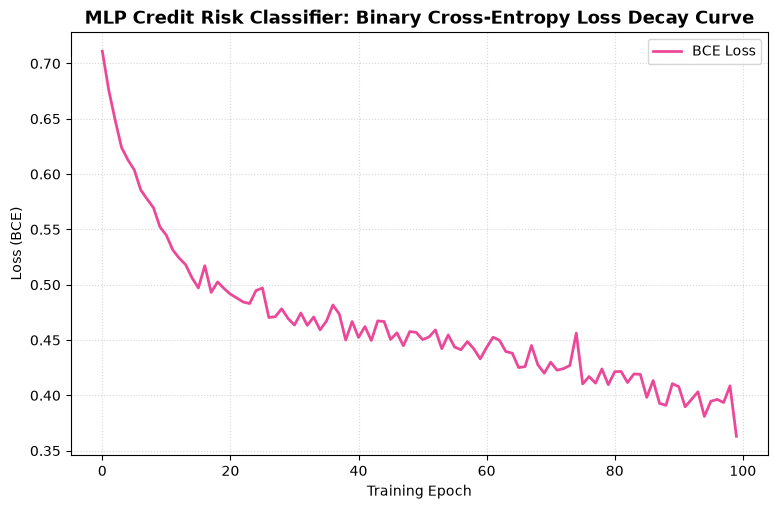

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#EC4899', linewidth=2.0, label='BCE Loss')

plt.title('MLP Credit Risk Classifier: Binary Cross-Entropy Loss Decay Curve', fontsize=13, fontweight='bold')
plt.xlabel('Training Epoch')
plt.ylabel('Loss (BCE)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
